<a href="https://colab.research.google.com/github/fauziahroikhanawar/sentimen_dana/blob/main/notebook/sentimen_dana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**KLASIFIKASI SENTIMEN ULASAN PENGGUNA TERHADAP LAYANAN E-WALLET DANA DI GOOGLE PLAY STORE**

Proyek Pemrosesan Teks Kelompok 8 kelas 2024A

Nama anggota:
1. Ulfia Nurmalizha Ramadhani (24031554064)
2. Aulia Aziza (24031554102)
3. Fauziah Roikhana Wardah (24031554162)

# SCRAPE

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
!pip install google_play_scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import Sort, reviews
result, ContinuationToken = reviews(
    'id.dana',
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=1000,
    filter_score_with=None
)

In [ ]:
def get_comment_dana():
    df_dana = pd.DataFrame(np.array(result),columns=['review']) #ubah jadi dataframe
    df_dana = df_dana.join(pd.DataFrame(df_dana.pop('review').tolist())) #nested dictionary ke bentuk kolom biasa
    df_dana = df_dana.rename(columns={'at':'date_time'})
    df_dana = df_dana.rename(columns={'userName':'username'})
    df_dana = df_dana.rename(columns={'content':'messages'})
    df_dana = df_dana.dropna(subset=['messages'], axis=0) #hapus baris tanpa messege
    df_dana['messages_low'] = df_dana['messages'].str.lower() #kolom baru versi lowercase
    df_dana = df_dana.drop_duplicates(['date_time', 'messages_low'], ignore_index=True) #hapus ulasan berdasarkan date time
    df_dana = df_dana.sort_values('date_time', ascending=False).reset_index(drop=True) #urutkan dari yang paling baru

    return df_dana

In [ ]:
df_train = get_comment_dana()
df_train

,reviewId,username,userImage,messages,score,thumbsUpCount,reviewCreatedVersion,date_time,replyContent,repliedAt,appVersion,messages_low
0,2d221732-ad67-47bf-a931-0f5906a03149,Silvester Novian,https://play-lh.googleusercontent.com/a-/ALV-U...,Sampai sekarang transaksi di aplikasi dana say...,1,0,2.106.0,2025-12-08 16:43:48,"Hi Kak, kami memahami kendala Kakak terkait ti...",2025-12-06 02:24:58,2.106.0,sampai sekarang transaksi di aplikasi dana say...
1,a395272d-d172-4955-b013-b26415f7ddcd,Heri Kane,https://play-lh.googleusercontent.com/a-/ALV-U...,"sudah 4 hari loh tidak bisa login, sampai seka...",1,0,2.106.0,2025-12-08 10:54:45,"Hi kak Heri, kami memahami rasa khawatir yg Ka...",2025-12-08 12:05:18,2.106.0,"sudah 4 hari loh tidak bisa login, sampai seka..."
2,65470ced-22fc-4c85-b59a-479b0dd132a0,Deffa Arra,https://play-lh.googleusercontent.com/a/ACg8oc...,"apk rusakk!!!! udah di coba hapus chace, resta...",1,0,2.80.0,2025-12-08 05:56:45,"Hi Kak Deffa, maaf ya, kami paham hal ini past...",2025-12-08 06:28:58,2.80.0,"apk rusakk!!!! udah di coba hapus chace, resta..."
3,98355567-169b-4856-8d0f-4710b98b24d9,Elly Ramadani,https://play-lh.googleusercontent.com/a/ACg8oc...,"Tolong lh ini kok g bisa daftar, udah dimasuka...",2,0,2.101.1,2025-12-08 01:38:38,"Hi Kak Elly, tentu Kami akan bantu Kendala kak...",2025-12-08 03:23:37,2.101.1,"tolong lh ini kok g bisa daftar, udah dimasuka..."
4,7cc6bac1-88d6-4acd-8007-108f3b679e92,Bowo Sulistiyo,https://play-lh.googleusercontent.com/a/ACg8oc...,semakin jelek aja tidak bisa login dan tiap lo...,1,1,2.106.0,2025-12-07 23:03:50,"Hi Kak Bowo, maaf atas ketidaknyamanannya terk...",2025-12-08 02:55:29,2.106.0,semakin jelek aja tidak bisa login dan tiap lo...
...,...,...,...,...,...,...,...,...,...,...,...,...
995,062ba756-7882-4356-af2b-9333dd84c86b,Rohmat Musa,https://play-lh.googleusercontent.com/a-/ALV-U...,"gk jadi ku kasih bintang 5, awalnya enak-enak ...",2,104,2.97.0,2025-09-17 07:52:38,"Hi Kak Rohmat, maaf udah bikin kamu ga tenang....",2025-09-17 17:46:14,2.97.0,"gk jadi ku kasih bintang 5, awalnya enak-enak ..."
996,4014897d-db35-400b-9693-9717cc91d889,Alif. dika,https://play-lh.googleusercontent.com/a-/ALV-U...,saya sudah upgrade ke premium sebelumnya dan m...,2,9,2.97.0,2025-09-17 03:27:36,"Hi Kak, maaf bikin gak nyaman. 🙏 Terkait kenda...",2025-09-17 05:20:00,2.97.0,saya sudah upgrade ke premium sebelumnya dan m...
997,7a2cff58-2280-4a13-b922-17aaab61ae3f,Sopian Husaini,https://play-lh.googleusercontent.com/a-/ALV-U...,"sistem keamanannya,sudah banyak yang mengalami...",1,1972,2.97.0,2025-09-16 12:39:28,None,NaT,2.97.0,"sistem keamanannya,sudah banyak yang mengalami..."
998,59bffcea-e2e2-49a0-b590-5d4cabb74dc0,Ikhsan Hidayat,https://play-lh.googleusercontent.com/a-/ALV-U...,saya isi pulsa dari aplikasi dana salto sudah ...,3,6,2.97.0,2025-09-16 09:08:01,"Hi Kak Ikhsan, mohon maaf atas ketidaknyamanan...",2025-09-16 10:48:11,2.97.0,saya isi pulsa dari aplikasi dana salto sudah ...


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              1000 non-null   object        
 1   username              1000 non-null   object        
 2   userImage             1000 non-null   object        
 3   messages              1000 non-null   object        
 4   score                 1000 non-null   int64         
 5   thumbsUpCount         1000 non-null   int64         
 6   reviewCreatedVersion  1000 non-null   object        
 7   date_time             1000 non-null   datetime64[ns]
 8   replyContent          851 non-null    object        
 9   repliedAt             851 non-null    datetime64[ns]
 10  appVersion            1000 non-null   object        
 11  messages_low          1000 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(8)
memory usage: 93.9+ KB


In [ ]:
df_train.to_excel('Data Sentiment DANA.xlsx')

# PRE-PROCESSING

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df_raw = pd.read_excel('/content/drive/MyDrive/UAS PEMTEKS/Data Sentiment DANA.xlsx')
df_raw.head()

,Unnamed: 0,reviewId,username,userImage,messages,score,thumbsUpCount,reviewCreatedVersion,date_time,replyContent,repliedAt,appVersion,messages_low
0,0,657ee880-eb0a-41f5-8783-0b4f54fe8565,HARUN ARRASYID,https://play-lh.googleusercontent.com/a/ACg8oc...,"sudah bagus sebenarnya, tapi dana cicil sering...",3,0,2.104.0,2025-11-21 18:05:03,"Hi Kak, kami pahami perasaan kamu. Tenang saja...",2025-11-22 06:49:55,2.104.0,"sudah bagus sebenarnya, tapi dana cicil sering..."
1,1,22f4417f-36f4-4d70-861c-348e45e63a86,kennedy turnip,https://play-lh.googleusercontent.com/a-/ALV-U...,"Aplikasinya makin lama making problems, server...",3,1,2.104.0,2025-11-21 17:43:30,"Hi Kak, Kami memahami ketidaknyamanan yg Kakak...",2025-11-22 07:39:54,2.104.0,"aplikasinya makin lama making problems, server..."
2,2,4d0acbad-21ab-48bb-829b-d12e53654a68,Nanang Juliana,https://play-lh.googleusercontent.com/a-/ALV-U...,dulu hilang uang dari dana suruh bikin laporan...,1,0,2.104.0,2025-11-21 17:10:14,"Hi Kak Nanang, kami turut prihatin atas keluha...",2025-11-22 07:31:30,2.104.0,dulu hilang uang dari dana suruh bikin laporan...
3,3,2e566efc-19a2-4bd9-a2a9-c8faeaa0fc8d,Fauzi Ramadhan,https://play-lh.googleusercontent.com/a-/ALV-U...,kami sangat kecewa karena proses ganti nomer h...,5,9,2.104.0,2025-11-21 16:36:30,"Hi Kak Fauzi, Kami memahami ketidaknyamanan yg...",2025-11-22 06:56:11,2.104.0,kami sangat kecewa karena proses ganti nomer h...
4,4,86ea517e-8044-4409-abbc-4aef31f2f48e,Dwi ardiyant Wibowo,https://play-lh.googleusercontent.com/a/ACg8oc...,tolong perbaiki di pembayaran QR nya masa mau ...,1,0,2.104.0,2025-11-21 16:21:12,"Hi Kak Dwi, maaf atas ketidaknyamanannya, kare...",2025-11-22 06:40:06,2.104.0,tolong perbaiki di pembayaran qr nya masa mau ...


In [ ]:
df = df_raw.copy()

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.9 MB/s eta 0:00:00


In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

list_stopwords = []
stopwords_sastrawi = StopWordRemoverFactory().get_stop_words()
list_stopwords.extend(stopwords_sastrawi)
list_stopwords = list(dict.fromkeys(list_stopwords)) #hapus stopword yang terduplikat
list_stopwords.sort()
len(list_stopwords)

123

In [ ]:
sw = pd.read_csv('/content/drive/MyDrive/UAS PEMTEKS/TextProcessing - Sheet1.csv')
sw['Stopwords'] = sw['Stopwords'].str.lower()
sw

,Stopwords
0,ada
1,adalah
2,adanya
3,adapun
4,agak
...,...
764,wkwkkk
765,wkwkwk
766,yaa
767,gimana


In [ ]:
list_stopwords += list(sw['Stopwords'])
list_stopwords = list(dict.fromkeys(list_stopwords))
list_stopwords.sort()
len(list_stopwords)

786

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import re
import string

stemmer_indo = StemmerFactory().create_stemmer()

normalisasi = {
    "bgt": "banget", "bg": "bang", "yg": "yang", "gk": "gak", "ga": "gak", "g": "gak",
    "ngga": "gak", "aja": "saja", "km": "kamu", "aku": "saya", "gw": "saya",
    "dr": "dari", "udh": "sudah", "tp": "tapi", "pls": "tolong","wkwk": "haha",
    "hehe": "haha", "mba": "mbak", "cndu": "candu", "bngt": "banget", "gue": "saya",
    "gua": "saya", "aq": "saya", "apk": "aplikasi", "ttp": "tetap","tpi": "tetapi",
    "tp": "tetapi", "appk":"aplikasi",
}

keep_words = ["tidak", "belum", "banget"] #list kata penting yang kalau dihapus bisa mempengaruhi sentimen
for w in keep_words: #jika ada di stopwords maka hapus dari situ
    if w in list_stopwords:
        list_stopwords.remove(w)

def remove_emojis(data):
    emoj = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002500-\U00002BEF"
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"
        u"\u3030"
                      "]+", re.UNICODE)
    return re.sub(emoj, '', data) #menghapus emoji dari teks


def clean_message(msg):
    msg = remove_emojis(msg)
    msg = msg.lower() # huruf kecil
    msg = re.sub(r'\s+', ' ', msg).strip() #hapus double spasi
    msg = re.sub(r'\d+', '', msg) # hapus angka
    msg = re.sub(r'https?://[^\s\n\r]+', '', msg) # hapus hyperlinks dan \s\n\r
    msg = re.sub(r'#[A-Za-z0-9]+', '', msg) #hapus hastag
    msg = re.sub(r'[^\x00-\x7f]',r'', msg) #hapus yang bukan utf8/ascii karakter seperti '\x9a\x91\x97\x9a\x97'
    for c in string.punctuation: # hapus tanda baca
        msg=msg.replace(c,' ')
    msg = ' '.join([normalisasi.get(w, w) for w in msg.split()]) #normal
    msg = ' '.join(msg.strip().split()) # memecah kalimat berdasarkan spasi  lalu menggabungkan menjadi string

    msg_fix = []
    for word in msg.split(): #stemming dan remove stopword
        stem_word_indo = stemmer_indo.stem(word)
        if stem_word_indo not in list_stopwords: #simpan kata yang bukan stopword saja
            msg_fix.append(stem_word_indo)
    return ' '.join(msg_fix)

In [ ]:
print("saya" in list_stopwords)

True


In [ ]:
list_stopwords.append("saya") #kemaren kata saya ga masuk stopword

In [ ]:
df = df_raw.copy(deep=True)
df['full_text_clean'] = df['messages'].apply(clean_message) #menerapkan fungsi clean message ke kolom message
df

,Unnamed: 0,reviewId,username,userImage,messages,score,thumbsUpCount,reviewCreatedVersion,date_time,replyContent,repliedAt,appVersion,messages_low,full_text_clean
0,0,657ee880-eb0a-41f5-8783-0b4f54fe8565,HARUN ARRASYID,https://play-lh.googleusercontent.com/a/ACg8oc...,"sudah bagus sebenarnya, tapi dana cicil sering...",3,0,2.104.0,2025-11-21 18:05:03,"Hi Kak, kami pahami perasaan kamu. Tenang saja...",2025-11-22 06:49:55,2.104.0,"sudah bagus sebenarnya, tapi dana cicil sering...",bagus dana cicil off tidak sedia limit saldo a...
1,1,22f4417f-36f4-4d70-861c-348e45e63a86,kennedy turnip,https://play-lh.googleusercontent.com/a-/ALV-U...,"Aplikasinya makin lama making problems, server...",3,1,2.104.0,2025-11-21 17:43:30,"Hi Kak, Kami memahami ketidaknyamanan yg Kakak...",2025-11-22 07:39:54,2.104.0,"aplikasinya makin lama making problems, server...",aplikasi making problems server error lapor an...
2,2,4d0acbad-21ab-48bb-829b-d12e53654a68,Nanang Juliana,https://play-lh.googleusercontent.com/a-/ALV-U...,dulu hilang uang dari dana suruh bikin laporan...,1,0,2.104.0,2025-11-21 17:10:14,"Hi Kak Nanang, kami turut prihatin atas keluha...",2025-11-22 07:31:30,2.104.0,dulu hilang uang dari dana suruh bikin laporan...,hilang uang dana suruh bikin lapor kepoliaian ...
3,3,2e566efc-19a2-4bd9-a2a9-c8faeaa0fc8d,Fauzi Ramadhan,https://play-lh.googleusercontent.com/a-/ALV-U...,kami sangat kecewa karena proses ganti nomer h...,5,9,2.104.0,2025-11-21 16:36:30,"Hi Kak Fauzi, Kami memahami ketidaknyamanan yg...",2025-11-22 06:56:11,2.104.0,kami sangat kecewa karena proses ganti nomer h...,kecewa proses ganti nomer hp hilang sulit emai...
4,4,86ea517e-8044-4409-abbc-4aef31f2f48e,Dwi ardiyant Wibowo,https://play-lh.googleusercontent.com/a/ACg8oc...,tolong perbaiki di pembayaran QR nya masa mau ...,1,0,2.104.0,2025-11-21 16:21:12,"Hi Kak Dwi, maaf atas ketidaknyamanannya, kare...",2025-11-22 06:40:06,2.104.0,tolong perbaiki di pembayaran qr nya masa mau ...,bayar qr beli kouta qris ganggu sinyal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,bc05af9a-5a80-442a-965a-3f31acf8f02a,Bambang Azhara,https://play-lh.googleusercontent.com/a/ACg8oc...,"Ada kendala tidak bisa masuk akun, sebab lupa ...",2,140,2.95.0,2025-09-03 11:03:14,"Hi Kak Bambang, kami siap bantu kendala Kakak ...",2025-09-03 12:44:36,2.95.0,"ada kendala tidak bisa masuk akun, sebab lupa ...",kendala tidak masuk akun lupa pin nomor tidak ...
996,996,ac875e6e-df2d-4b14-9451-1da6bd312c66,Yarr Sunandar,https://play-lh.googleusercontent.com/a/ACg8oc...,Yap sangat bagus pengiriman cepat dan Pajak tf...,3,35,2.94.1,2025-09-01 15:23:48,NaN,NaT,2.94.1,yap sangat bagus pengiriman cepat dan pajak tf...,yap bagus kirim cepat pajak tf sayang no hilan...
997,997,22d3ce45-b6f0-4631-9610-60db89823c88,Henzi Renanda,https://play-lh.googleusercontent.com/a-/ALV-U...,"apknya bagus,transaksi ga pernah bermasalah,na...",5,370,2.94.1,2025-09-01 08:53:43,NaN,NaT,2.94.1,"apknya bagus,transaksi ga pernah bermasalah,na...",apknya bagus transaksi nabung aman bangett rek...
998,998,6a780a7a-82c8-4f63-a80b-828c9cfa60ae,Balqis Nazwani,https://play-lh.googleusercontent.com/a/ACg8oc...,"jelek bnget, cuman mau login gak bisa, ktp sud...",1,35,2.94.1,2025-09-01 03:57:10,"Hi Kak Balqia, Kami memahami keluhan kamu. Per...",2025-09-01 05:04:36,2.94.1,"jelek bnget, cuman mau login gak bisa, ktp sud...",jelek bnget cuman login ktp verifikasi wajah c...


In [ ]:
def reduce_repeated_char(text):
    return re.sub(r'(.)\1+', r'\1', text)

In [ ]:
df['full_text_clean'] = df['full_text_clean'].apply(reduce_repeated_char)

In [ ]:
from collections import Counter

all_words = " ".join(df['full_text_clean']).split()
word_counts = Counter(all_words)
least_20 = word_counts.most_common()[:-21:-1]
least_20

[('nyicil', 1),
 ('blanja', 1),
 ('bnr', 1),
 ('yap', 1),
 ('diperibet', 1),
 ('instruksi', 1),
 ('tetring', 1),
 ('what', 1),
 ('cust', 1),
 ('name', 1),
 ('ketemu', 1),
 ('ajuin', 1),
 ('agustus', 1),
 ('konsisten', 1),
 ('cuan', 1),
 ('celah', 1),
 ('jebol', 1),
 ('inbox', 1),
 ('gasemua', 1),
 ('conect', 1)]

In [ ]:
least_fix = {
    'blanja': 'belanja',
    'bnr': 'benar',
    'what': 'apa',
}

def apply_fix(text, mapping):
    return ' '.join([mapping.get(w, w) for w in text.split()])

df['full_text_clean'] = df['full_text_clean'].apply(lambda x: apply_fix(x, least_fix))

In [ ]:
df = df[['messages', 'full_text_clean', 'score']] #butuh kolom ini saja
df.head()

,messages,full_text_clean,score
0,"sudah bagus sebenarnya, tapi dana cicil sering...",bagus dana cicil of tidak sedia limit saldo ap...,3
1,"Aplikasinya makin lama making problems, server...",aplikasi making problems server eror lapor ana...,3
2,dulu hilang uang dari dana suruh bikin laporan...,hilang uang dana suruh bikin lapor kepoliaian ...,1
3,kami sangat kecewa karena proses ganti nomer h...,kecewa proses ganti nomer hp hilang sulit emai...,5
4,tolong perbaiki di pembayaran QR nya masa mau ...,bayar qr beli kouta qris gangu sinyal,1


In [ ]:
df.to_excel('/content/drive/MyDrive/UAS PEMTEKS/Data Sentiment DANA-PREPO.xlsx', index=False)

# EDA

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/UAS PEMTEKS/Data Sentiment DANA-PREPO.xlsx')
df.head()

,messages,full_text_clean,score
0,"sudah bagus sebenarnya, tapi dana cicil sering...",bagus dana cicil of tidak sedia limit saldo ap...,3
1,"Aplikasinya makin lama making problems, server...",aplikasi making problems server eror lapor ana...,3
2,dulu hilang uang dari dana suruh bikin laporan...,hilang uang dana suruh bikin lapor kepoliaian ...,1
3,kami sangat kecewa karena proses ganti nomer h...,kecewa proses ganti nomer hp hilang sulit emai...,5
4,tolong perbaiki di pembayaran QR nya masa mau ...,bayar qr beli kouta qris gangu sinyal,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   messages         1000 non-null   object
 1   full_text_clean  1000 non-null   object
 2   score            1000 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 23.6+ KB


In [ ]:
df.score.value_counts() #rating app

,count
score,
1,552
5,157
2,122
3,104
4,65


In [ ]:
count_wd = []
for word in df['full_text_clean']:
    count = len(word.split()) #jumlah kata per teks
    count_wd.append(count) #masukkan ke list
df['count_words'] = count_wd
df

,messages,full_text_clean,score,count_words
0,"sudah bagus sebenarnya, tapi dana cicil sering...",bagus dana cicil of tidak sedia limit saldo ap...,3,13
1,"Aplikasinya makin lama making problems, server...",aplikasi making problems server eror lapor ana...,3,45
2,dulu hilang uang dari dana suruh bikin laporan...,hilang uang dana suruh bikin lapor kepoliaian ...,1,13
3,kami sangat kecewa karena proses ganti nomer h...,kecewa proses ganti nomer hp hilang sulit emai...,5,28
4,tolong perbaiki di pembayaran QR nya masa mau ...,bayar qr beli kouta qris gangu sinyal,1,7
...,...,...,...,...
995,"Ada kendala tidak bisa masuk akun, sebab lupa ...",kendala tidak masuk akun lupa pin nomor tidak ...,2,22
996,Yap sangat bagus pengiriman cepat dan Pajak tf...,yap bagus kirim cepat pajak tf sayang no hilan...,3,22
997,"apknya bagus,transaksi ga pernah bermasalah,na...",apknya bagus transaksi nabung aman banget reko...,5,37
998,"jelek bnget, cuman mau login gak bisa, ktp sud...",jelek bnget cuman login ktp verifikasi wajah c...,1,22


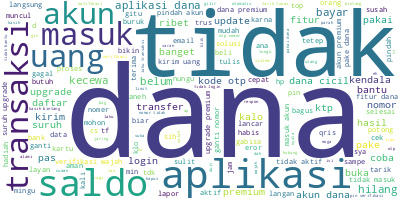

In [ ]:
#analisis kata yang paling sering muncul
import matplotlib.pyplot as plt
import seaborn as sns #plotting statistik
from wordcloud import WordCloud

long_string = ','.join(list(df['full_text_clean'].values)) #gabungkan teks menjadi satu string
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')
wordcloud.generate(long_string)
wordcloud.to_image()

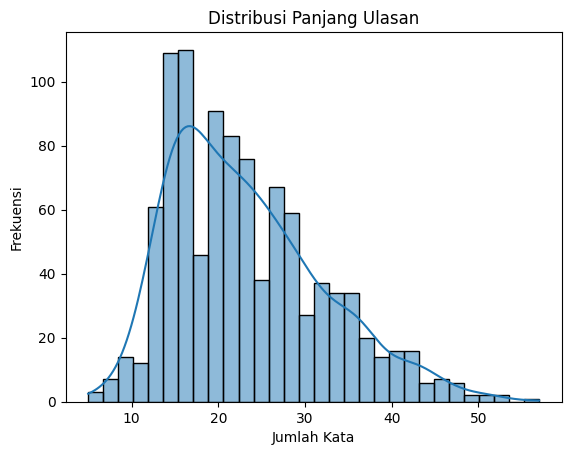

In [ ]:
df['clean_length'] = df['full_text_clean'].apply(lambda x: len(str(x).split()))
sns.histplot(df['clean_length'], bins=30, kde=True)
plt.title("Distribusi Panjang Ulasan")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

/tmp/ipython-input-914124184.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[x[1] for x in top_words], y=[x[0] for x in top_words], palette="Blues_d")


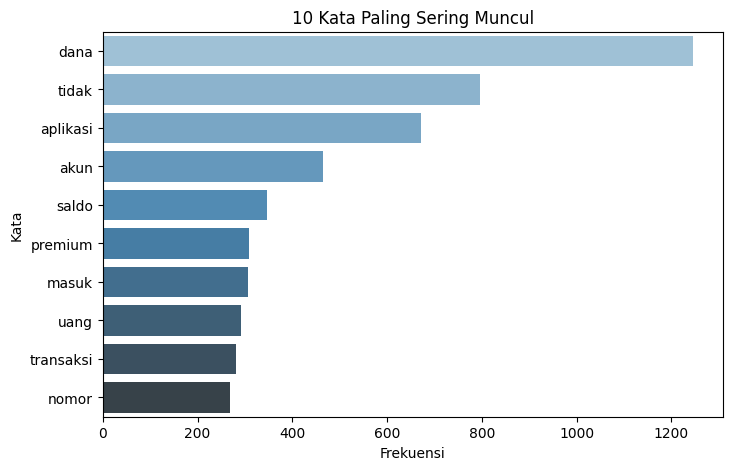

In [ ]:
#10 kata yang paling sering muncul
from collections import Counter #menghitung kata
top_words = Counter(" ".join(df['full_text_clean']).split()).most_common(10)

plt.figure(figsize=(8,5))
sns.barplot(x=[x[1] for x in top_words], y=[x[0] for x in top_words], palette="Blues_d")
plt.title("10 Kata Paling Sering Muncul")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.show()

/tmp/ipython-input-1189992741.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='score', data=df, palette='viridis')


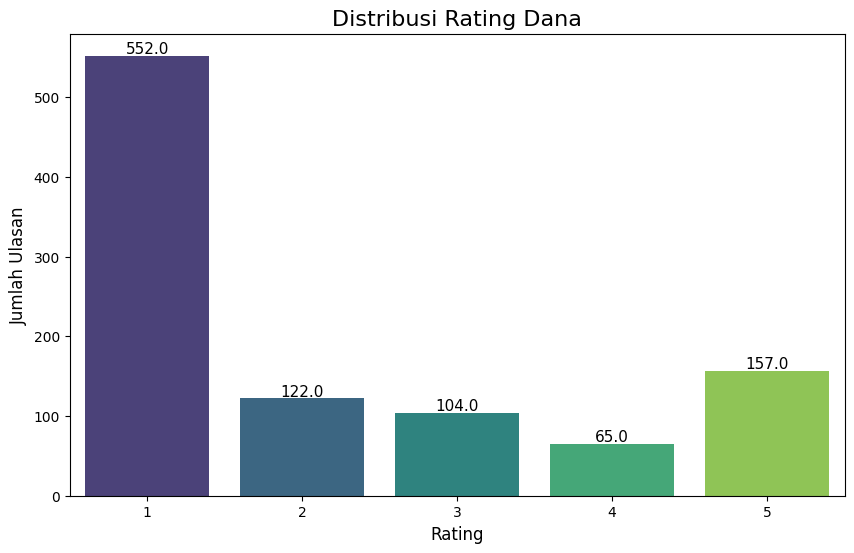


Rata-rata Rating: 2.15
Median Rating: 1.0


In [ ]:
#sebaran rating aplikasis dana dari pengguna
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='score', data=df, palette='viridis')
ax.set_title('Distribusi Rating Dana', fontsize=16)
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Jumlah Ulasan', fontsize=12)

for p in ax.patches: #menambahkan notasi angka diujung bar
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

average_rating = df['score'].mean()
median_rating = df['score'].median()

print(f"\nRata-rata Rating: {average_rating:.2f}")
print(f"Median Rating: {median_rating}")

# Pelabelan based lexicon

In [ ]:
!wget https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv -O positive.tsv
!wget https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv -O negative.tsv

--2025-12-15 16:31:25--  https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 41462 (40K) [text/plain]
Saving to: ‘positive.tsv’

positive.tsv        100%[===================>]  40.49K  --.-KB/s    in 0.01s   

2025-12-15 16:31:25 (3.54 MB/s) - ‘positive.tsv’ saved [41462/41462]

--2025-12-15 16:31:25--  https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82788 (81K) [text/plain]
Saving to: ‘negative.tsv’


In [ ]:
pos_df = pd.read_csv("positive.tsv", sep="\t", header=0)
neg_df = pd.read_csv("negative.tsv", sep="\t", header=0)

In [ ]:
pos_df.head()
pos_df.columns

Index(['word', 'weight'], dtype='object')

In [ ]:
positive_lex = {w: int(s) for w, s in zip(pos_df["word"], pos_df["weight"])}
negative_lex = {w: -abs(int(s)) for w, s in zip(neg_df["word"], neg_df["weight"])}
inset_lex = {**positive_lex, **negative_lex}

In [ ]:
def auto_label_inset(text):
    text = str(text).split()
    total_score = 0

    for word in text:
        if word in inset_lex:
            total_score += inset_lex[word]

    if total_score > 0:
        return 'positif'
    elif total_score < 0:
        return 'negatif'
    else:
        return 'netral'

In [ ]:
df['label_inset'] = df['full_text_clean'].apply(auto_label_inset)

In [ ]:
df['label_inset'].value_counts()

,count
label_inset,
negatif,797
positif,189
netral,14


In [ ]:
df.to_excel('/content/drive/MyDrive/UAS PEMTEKS/Data Sentiment DANA label.xlsx', index=False)

# Feature Engineering

In [ ]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
df[df['full_text_clean'].str.len() < 2].head() #cek apakah ada teks yang kosong

,messages,full_text_clean,score,count_words,clean_length,label_inset


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,#biar tidak terlalu banya fiturnya
    ngram_range=(1,2),
    token_pattern=r'(?u)\b[a-zA-Z]{2,}\b'   # minimal 2 huruf
)

X_tfidf = vectorizer.fit_transform(df['full_text_clean'])

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())

tfidf_df.head()

,abal,abis,abis gaji,abis klik,abis pulsa,abis sengah,abis susah,abis transaksi,abisa,abisa uang,...,youtube,yoyo,yoyo voice,yth,yth dana,yth mnulis,yuk,yuk pdhl,yuk upgrade,zonk
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
tfidf_df.sample(10)

,abal,abis,abis gaji,abis klik,abis pulsa,abis sengah,abis susah,abis transaksi,abisa,abisa uang,...,youtube,yoyo,yoyo voice,yth,yth dana,yth mnulis,yuk,yuk pdhl,yuk upgrade,zonk
353,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.202881
662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
138,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
407,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
373,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
559,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
848,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
192,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [ ]:
len(vectorizer.get_feature_names_out()) #menghitung jumlah fitur/kata yang unik

5000

In [ ]:
(tfidf_df.sum(axis=1) > 0).value_counts() #cek ada tidaknya baris yang punya value lbh dari 0

,count
True,1000


In [ ]:
tfidf_df.sum().sort_values(ascending=False).head(20) #20 kata dengan bobot total tertinggi, alias sering muncul

,0
dana,55.320958
tidak,46.897974
aplikasi,40.574409
akun,33.590205
premium,26.553851
saldo,26.417601
masuk,24.887331
uang,24.793293
transaksi,24.359651
nomor,23.905485


# EDA PART 2

In [ ]:
print("Shape TF-IDF:", tfidf_df.shape) #jumlah data x jumlah fitur
print("\nDeskripsi:")
print(tfidf_df.describe())

Shape TF-IDF: (1000, 5000)

Deskripsi:
              abal         abis    abis gaji    abis klik   abis pulsa  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.000506     0.001167     0.000283     0.000188     0.000180   
std       0.015986     0.015523     0.008941     0.005935     0.005701   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     0.000000     0.000000     0.000000   
50%       0.000000     0.000000     0.000000     0.000000     0.000000   
75%       0.000000     0.000000     0.000000     0.000000     0.000000   
max       0.505517     0.288819     0.282733     0.187683     0.180291   

       abis sengah   abis susah  abis transaksi        abisa   abisa uang  \
count  1000.000000  1000.000000     1000.000000  1000.000000  1000.000000   
mean      0.000210     0.000201        0.000349     0.000194     0.000194   
std       0.006639     0.006370        0.011052     0.006128   

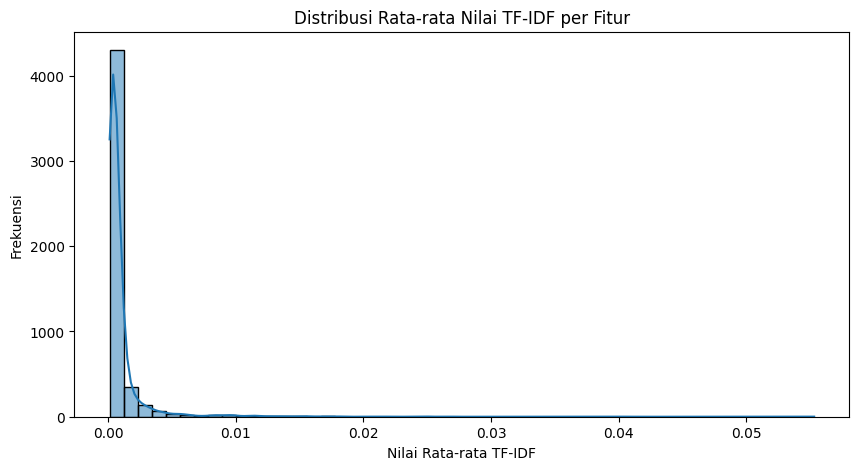

In [ ]:
mean_tfidf = tfidf_df.mean(axis=0).sort_values(ascending=False) #rata-rata nilai tfidf lalu diurutkan dari yang paling tinggi
plt.figure(figsize=(10,5))
sns.histplot(mean_tfidf, bins=50, kde=True)
plt.title("Distribusi Rata-rata Nilai TF-IDF per Fitur")
plt.xlabel("Nilai Rata-rata TF-IDF")
plt.ylabel("Frekuensi")
plt.show()

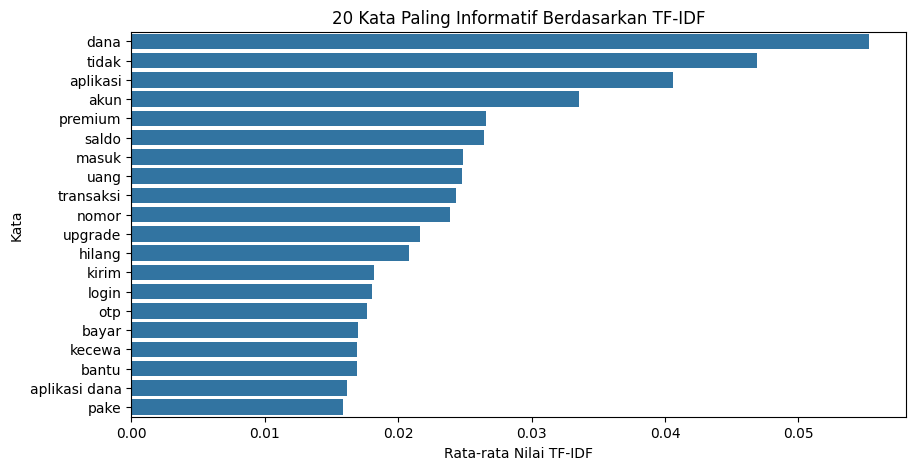

In [ ]:
top_words = mean_tfidf.head(20) #20 kata dengan nilai tfidf paling tinggi
plt.figure(figsize=(10,5))
sns.barplot(x=top_words.values, y=top_words.index)
plt.title("20 Kata Paling Informatif Berdasarkan TF-IDF")
plt.xlabel("Rata-rata Nilai TF-IDF")
plt.ylabel("Kata")
plt.show()

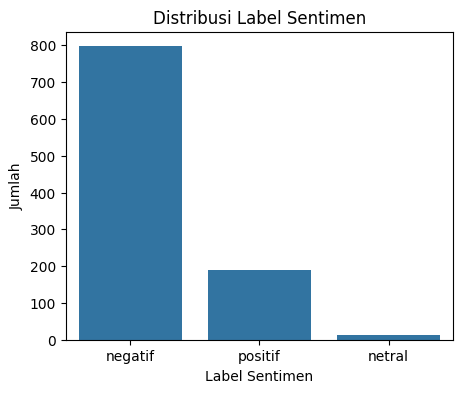

In [ ]:
plt.figure(figsize=(5,4)) #visualisasi hasil pelabelan manual
sns.countplot(x=df['label_inset'])
plt.title("Distribusi Label Sentimen")
plt.xlabel("Label Sentimen")
plt.ylabel("Jumlah")
plt.show()

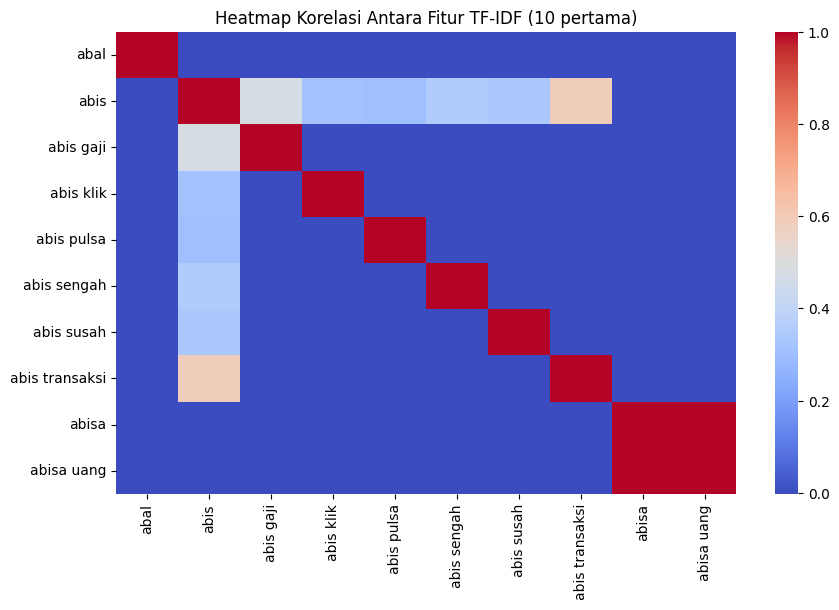

In [ ]:
sample_features = tfidf_df.iloc[:, :10]
corr = sample_features.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Heatmap Korelasi Antara Fitur TF-IDF (10 pertama)")
plt.show()

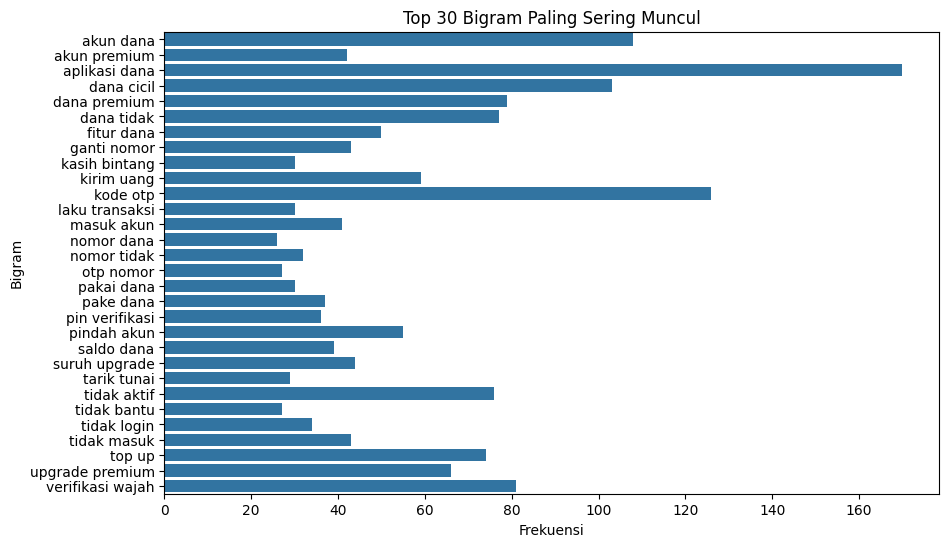

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=30)
bigram_matrix = bigram_vectorizer.fit_transform(df['full_text_clean'])
bigram_freq = bigram_matrix.toarray().sum(axis=0)
bigram_terms = bigram_vectorizer.get_feature_names_out()

plt.figure(figsize=(10,6))
sns.barplot(x=bigram_freq, y=bigram_terms)
plt.title('Top 30 Bigram Paling Sering Muncul')
plt.xlabel('Frekuensi')
plt.ylabel('Bigram')
plt.show()

# Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split

X = X_tfidf

y = df['label_inset']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data training:", X_train.shape)
print("Data testing:", X_test.shape)

Data training: (800, 5000)
Data testing: (200, 5000)


# Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train) #latih menggunakan data training

y_pred_nb = nb_model.predict(X_test)

print("Prediksi Sentimen Naive Bayes:")
print(y_pred_nb[:20])

Prediksi Sentimen Naive Bayes:
['negatif' 'negatif' 'negatif' 'negatif' 'negatif' 'negatif' 'negatif'
 'negatif' 'negatif' 'negatif' 'negatif' 'negatif' 'negatif' 'negatif'
 'negatif' 'negatif' 'negatif' 'negatif' 'negatif' 'negatif']


# SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', C=1)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("Prediksi SVM (20 contoh):")
print(y_pred_svm[:20])

Prediksi SVM (20 contoh):
['negatif' 'negatif' 'negatif' 'negatif' 'negatif' 'negatif' 'negatif'
 'negatif' 'negatif' 'negatif' 'negatif' 'negatif' 'negatif' 'negatif'
 'negatif' 'negatif' 'negatif' 'negatif' 'negatif' 'negatif']


# Evaluasi

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Evaluasi Naive Bayes:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))

print("Evaluasi SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

Evaluasi Naive Bayes:
Accuracy: 0.835
              precision    recall  f1-score   support

     negatif       0.83      1.00      0.91       167
      netral       0.00      0.00      0.00         3
     positif       0.00      0.00      0.00        30

    accuracy                           0.83       200
   macro avg       0.28      0.33      0.30       200
weighted avg       0.70      0.83      0.76       200

[[167   0   0]
 [  3   0   0]
 [ 30   0   0]]
Evaluasi SVM
Accuracy: 0.87
              precision    recall  f1-score   support

     negatif       0.87      0.99      0.93       167
      netral       0.00      0.00      0.00         3
     positif       0.89      0.27      0.41        30

    accuracy                           0.87       200
   macro avg       0.59      0.42      0.45       200
weighted avg       0.86      0.87      0.84       200

[[166   0   1]
 [  3   0   0]
 [ 22   0   8]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
#dataframe baru berisi hasil prediksi
df_result = df[['messages', 'full_text_clean', 'label_inset']].copy()

df_result['pred_nb'] = nb_model.predict(X_tfidf)
df_result['pred_svm'] = svm_model.predict(X_tfidf)

df_result.head()

,messages,full_text_clean,label_inset,pred_nb,pred_svm
0,"sudah bagus sebenarnya, tapi dana cicil sering...",bagus dana cicil of tidak sedia limit saldo ap...,negatif,negatif,negatif
1,"Aplikasinya makin lama making problems, server...",aplikasi making problems server eror lapor ana...,negatif,negatif,negatif
2,dulu hilang uang dari dana suruh bikin laporan...,hilang uang dana suruh bikin lapor kepoliaian ...,negatif,negatif,negatif
3,kami sangat kecewa karena proses ganti nomer h...,kecewa proses ganti nomer hp hilang sulit emai...,negatif,negatif,negatif
4,tolong perbaiki di pembayaran QR nya masa mau ...,bayar qr beli kouta qris gangu sinyal,negatif,negatif,negatif


In [ ]:
df_result.to_excel('/content/drive/MyDrive/UAS PEMTEKS/Data Sentiment DANA pemodelan.xlsx', index=False)

# Final EDA

In [ ]:
print("Distribusi Prediksi Naive Bayes:")
print(df_result['pred_nb'].value_counts())

Distribusi Prediksi Naive Bayes:
pred_nb
negatif    997
positif      3
Name: count, dtype: int64


In [ ]:
print("\nDistribusi Prediksi SVM:")
print(df_result['pred_svm'].value_counts())


Distribusi Prediksi SVM:
pred_svm
negatif    833
positif    167
Name: count, dtype: int64


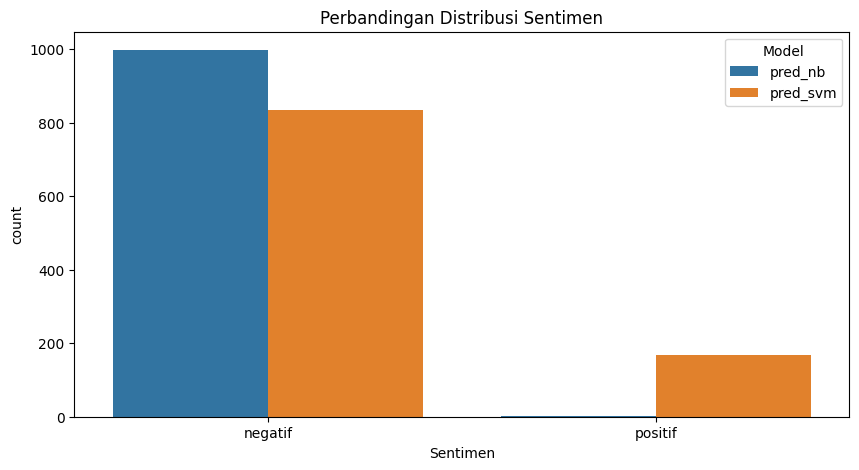

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(data=df_result.melt(value_vars=["pred_nb", "pred_svm"], var_name="Model", value_name="Sentimen"),
x="Sentimen", hue="Model")
plt.title("Perbandingan Distribusi Sentimen")
plt.show()

In [ ]:
df_mismatch = df_result[df_result['pred_nb'] != df_result['pred_svm']]
df_mismatch.head()

,messages,full_text_clean,label_inset,pred_nb,pred_svm
13,ini apaan si mau transaksi suruh upgrade premi...,si transaksi suruh upgrade premium trs nurut u...,positif,negatif,positif
16,ini saya lasi bintang 1 karena pas saya mau la...,lasi bintang pas langan dana premium tidak nar...,positif,negatif,positif
17,"min, kenapa saldo dana+ gk bisa ditarik ya🥲 se...",min saldo dana tarik narik notif ups kendala p...,positif,negatif,positif
18,"Kemudahan penggunaan, iya. Tapi minus di keadi...",mudah iya minus adil dana tunai urus pakai dui...,positif,negatif,positif
22,"kak tolong knp dana saya eror trs , saya awaln...",kak knp dana eror trs top up game masuk sandi ...,positif,negatif,positif


In [ ]:
len(df_mismatch) #menampilkan yanng tidak samanya berapa

164

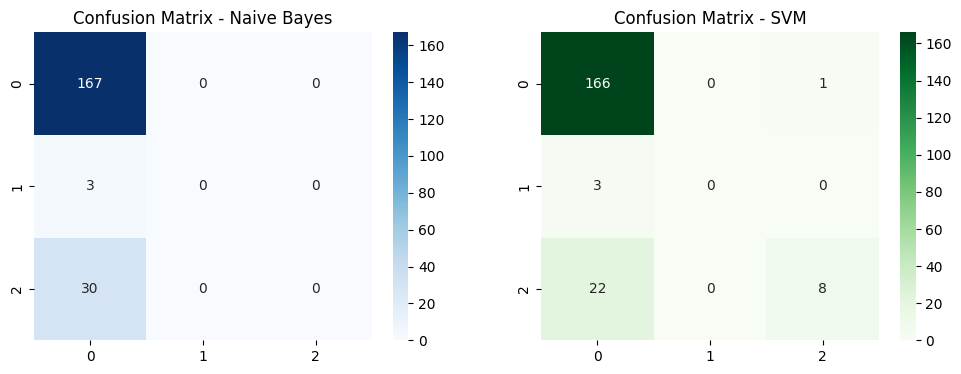

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - Naive Bayes")

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, cmap="Greens", fmt="d")
plt.title("Confusion Matrix - SVM")

plt.show()

# K-Means

In [ ]:
df_pos = df[df['label_inset'] == 'positif']
df_neg = df[df['label_inset'] == 'negatif']

# Positif

In [ ]:
vectorizer_pos = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    token_pattern=r'(?u)\b[a-zA-Z]{2,}\b'
)

X_pos = vectorizer_pos.fit_transform(df_pos['full_text_clean'])

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 8)
sil_pos = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pos)
    sil_pos.append(silhouette_score(X_pos, labels))

best_k_pos = K_range[sil_pos.index(max(sil_pos))]
print("K terbaik positif:", best_k_pos)

K terbaik positif: 7


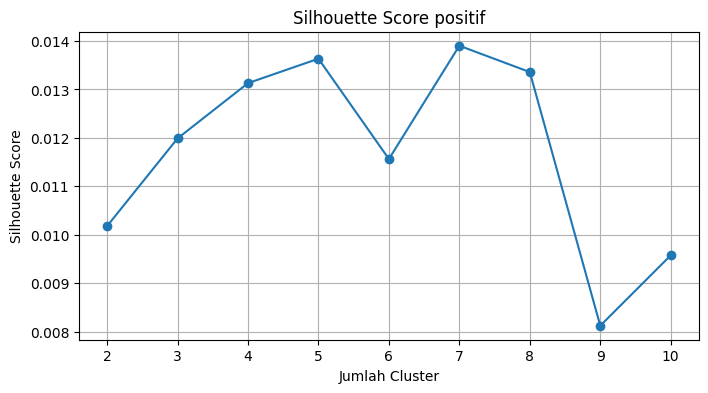

In [ ]:
K_range = range(2, 11)
sil_pos = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pos)
    sil_pos.append(silhouette_score(X_pos, labels))

plt.figure(figsize=(8,4))
plt.plot(K_range, sil_pos, marker='o')
plt.title('Silhouette Score positif')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [ ]:
kmeans_pos = KMeans(n_clusters=best_k_pos, random_state=42, n_init=10)
clusters_pos = kmeans_pos.fit_predict(X_pos)
df_pos['cluster'] = clusters_pos

/tmp/ipython-input-1902637348.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pos['cluster'] = clusters_pos


In [ ]:
centroids_pos = kmeans_pos.cluster_centers_
feat_pos = vectorizer_pos.get_feature_names_out()

topn = 20
for i in range(best_k_pos):
    idx = centroids_pos[i].argsort()[::-1][:topn]
    print(f"\nCLUSTER POSITIF {i}")
    print([feat_pos[j] for j in idx])


CLUSTER POSITIF 0
['dana', 'akun', 'akun dana', 'lapor', 'min', 'saldo', 'hilang', 'tidak', 'terima', 'kecewa', 'kirim', 'chat', 'cs', 'masuk', 'transaksi', 'pakai', 'kak', 'bukti', 'kalo', 'hilang saldo']

CLUSTER POSITIF 1
['bisnis', 'dana', 'dana bisnis', 'proses', 'transaksi', 'tarik', 'jual', 'coba', 'saldo', 'uang', 'bayar', 'tidak', 'aplikasi', 'qr', 'cair', 'stabil', 'tari', 'reksa', 'reksa dana', 'jam']

CLUSTER POSITIF 2
['cicil', 'dana cicil', 'dana', 'fitur', 'fitur dana', 'muncul', 'transaksi', 'aplikasi', 'juta', 'tidak', 'kasih', 'belum', 'instan', 'dana instan', 'bintang', 'limit', 'aplikasi dana', 'akun', 'kecewa', 'kasih bintang']

CLUSTER POSITIF 3
['premium', 'dana', 'dana premium', 'update', 'aplikasi dana', 'aplikasi', 'tarik', 'diupgrade', 'ngk', 'jdi', 'premium update', 'belum', 'tungu', 'akun', 'kasih', 'transaksi', 'kasih bintang', 'pas', 'verifikasi', 'bintang']

CLUSTER POSITIF 4
['upgrade', 'premium', 'kirim', 'uang', 'upgrade premium', 'kirim uang', 'suru

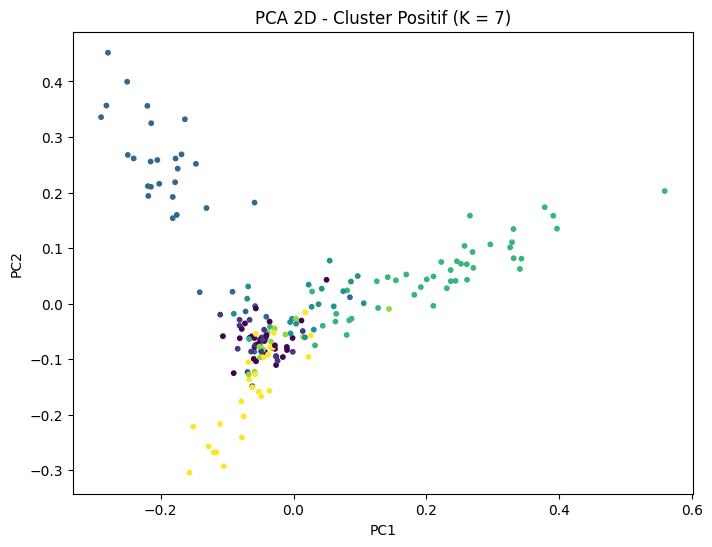

In [ ]:
from sklearn.decomposition import PCA
pca_pos = PCA(n_components=2)
pos_2d = pca_pos.fit_transform(X_pos.toarray())

plt.figure(figsize=(8,6))
plt.scatter(pos_2d[:,0], pos_2d[:,1], c=df_pos['cluster'], s=10)
plt.title(f"PCA 2D - Cluster Positif (K = {best_k_pos})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

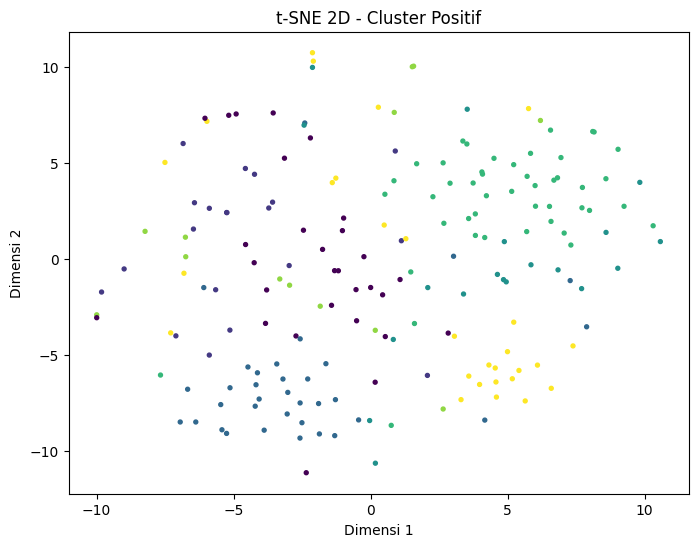

In [ ]:
from sklearn.manifold import TSNE
import umap.umap_ as umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

tsne_pos = TSNE(n_components=2, perplexity=40, random_state=42)
tsne_pos_res = tsne_pos.fit_transform(X_pos.toarray())

plt.figure(figsize=(8,6))
plt.scatter(tsne_pos_res[:,0], tsne_pos_res[:,1], c=df_pos['cluster'], s=8)
plt.title("t-SNE 2D - Cluster Positif")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.show()

# Negatif

In [ ]:
vectorizer_neg = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    token_pattern=r'(?u)\b[a-zA-Z]{2,}\b'
)

X_neg = vectorizer_neg.fit_transform(df_neg['full_text_clean'])

In [ ]:
sil_neg = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_neg)
    sil_neg.append(silhouette_score(X_neg, labels))

best_k_neg = K_range[sil_neg.index(max(sil_neg))]
print("K terbaik negatif:", best_k_neg)

K terbaik negatif: 6


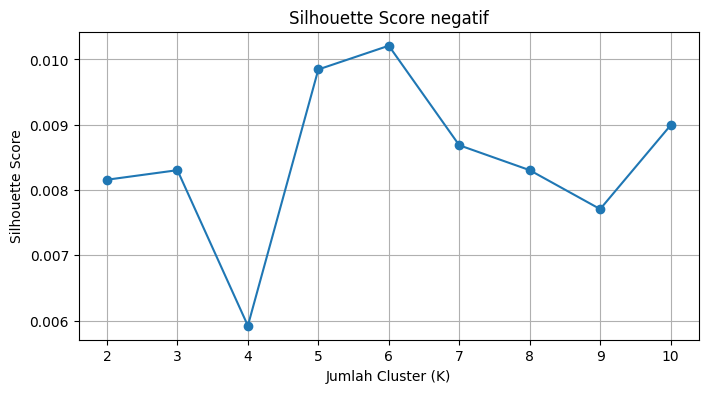

In [ ]:
sil_neg = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_neg)
    sil_neg.append(silhouette_score(X_neg, labels))

plt.figure(figsize=(8,4))
plt.plot(K_range, sil_neg, marker='o')
plt.title('Silhouette Score negatif')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [ ]:
kmeans_neg = KMeans(n_clusters=best_k_neg, random_state=42, n_init=10)
clusters_neg = kmeans_neg.fit_predict(X_neg)
df_neg['cluster'] = clusters_neg

/tmp/ipython-input-2394395505.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_neg['cluster'] = clusters_neg


In [ ]:
centroids_neg = kmeans_neg.cluster_centers_
feat_neg = vectorizer_neg.get_feature_names_out()

for i in range(best_k_neg):
    idx = centroids_neg[i].argsort()[::-1][:topn]
    print(f"\nCLUSTER NEGATIF {i}")
    print([feat_neg[j] for j in idx])


CLUSTER NEGATIF 0
['cicil', 'dana cicil', 'dana', 'fitur', 'tidak', 'cicil tidak', 'fitur dana', 'limit', 'sedia', 'pakai', 'tidak sedia', 'bayar', 'muncul', 'transaksi', 'aplikasi', 'limit dana', 'mudah', 'aju dana', 'akun', 'kasih']

CLUSTER NEGATIF 1
['upgrade', 'premium', 'upgrade premium', 'suruh upgrade', 'suruh', 'akun', 'kirim', 'uang', 'tidak', 'dana', 'aplikasi', 'muncul', 'kirim uang', 'dana premium', 'klik', 'transfer', 'upgrade dana', 'ktp', 'pakai', 'foto']

CLUSTER NEGATIF 2
['masuk', 'aplikasi', 'dana', 'bagus', 'update', 'tidak', 'buka', 'jaring', 'saldo', 'uang', 'aplikasi dana', 'data', 'transaksi', 'coba', 'banget', 'eror', 'kalo', 'tidak masuk', 'mohon', 'beli']

CLUSTER NEGATIF 3
['dana', 'tidak', 'aplikasi', 'akun', 'transaksi', 'bantu', 'kecewa', 'premium', 'kali', 'nomer', 'hadiah', 'banget', 'daftar', 'uang', 'aplikasi dana', 'cs', 'dana tidak', 'ganti', 'nomor', 'saldo']

CLUSTER NEGATIF 4
['bayar', 'saldo', 'aplikasi', 'tidak', 'uang', 'potong', 'dana', 'am

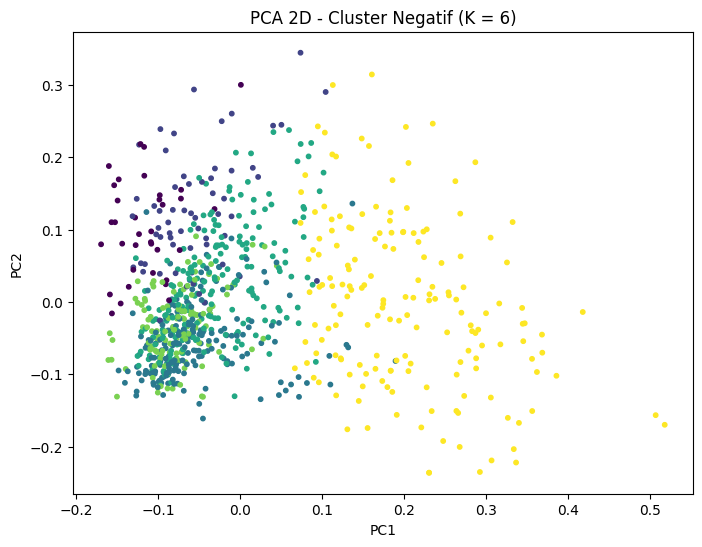

In [ ]:
pca_neg = PCA(n_components=2)
neg_2d = pca_neg.fit_transform(X_neg.toarray())

plt.figure(figsize=(8,6))
plt.scatter(neg_2d[:,0], neg_2d[:,1], c=df_neg['cluster'], s=10)
plt.title(f"PCA 2D - Cluster Negatif (K = {best_k_neg})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

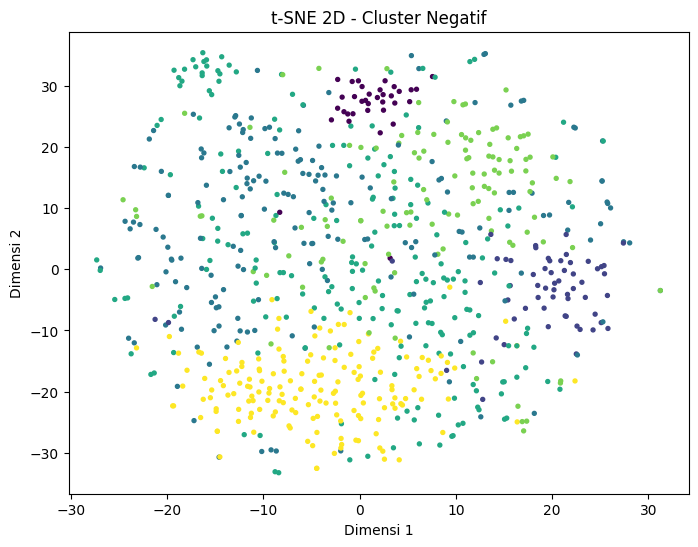

In [ ]:
tsne_neg = TSNE(n_components=2, perplexity=40, random_state=42)
tsne_neg_res = tsne_neg.fit_transform(X_neg.toarray())

plt.figure(figsize=(8,6))
plt.scatter(tsne_neg_res[:,0], tsne_neg_res[:,1], c=df_neg['cluster'], s=8)
plt.title("t-SNE 2D - Cluster Negatif")
plt.xlabel("Dimensi 1")
plt.ylabel("Dimensi 2")
plt.show()